In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import h5py

## define function

In [ ]:
SNAPS = range(21, 50)
BASE  = Path("****")# Path settings

def load_magnitudes(i):
    H5 = BASE / f"Uchuu_nu2GC_lightcone_snap{i}.hdf5"
    with h5py.File(H5, "r") as f:
        zsnap = float(f["Header"].attrs["zsnap"])
        g = f["g_mag"][:]
        r = f["r_mag"][:]
        z = f["z_mag"][:]
        halomass = f["HaloMass"][:] 

    return zsnap, g, r, z, halomass


def make_gr_rz(g, r, z):
    m = np.isfinite(g) & np.isfinite(r) & np.isfinite(z)
    gr = (g - r)[m]
    rz = (r - z)[m]
    return rz, gr, m

In [14]:
def elg_lower_line(rz):
    """共通境界線:g-r = 0.5*(r-z) + 0.1"""
    return 0.5 * rz + 0.1

def elg_lop_upper_line(rz):
    """LOP境界線:g-r = -1.2*(r-z) + 1.3"""
    return -1.2 * rz + 1.3

def elg_vlo_upper_line(rz):
    """VLO境界線:g-r = -1.2*(r-z) + 1.6"""
    return -1.2 * rz + 1.6

def elg_rz_min():
    """r-zの最小値(縦線): r-z = 0.15"""
    return 0.15
    
def elg_common_region_mask(rz, gr):
    """
    共通領域:
      r-z >= 0.15
      g-r <= 0.5*(r-z) + 0.1
    """
    return (rz >= elg_rz_min()) & (gr <= elg_lower_line(rz)) 

def elg_lop_mask(rz, gr):
    """
    LOPの領域:
      共通領域 
      g-r <= -1.2*(r-z) + 1.3
    """
    m = elg_common_region_mask(rz, gr)
    m &= (gr <= elg_lop_upper_line(rz))
    return m   

def elg_vlo_mask(rz, gr):
    """
    VLOの領域:
      共通領域 かつ
      g-r >= -1.2*(r-z) + 1.3
      g-r <= -1.2*(r-z) + 1.6
    """
    m = elg_common_region_mask(rz, gr)
    m &= (gr <= elg_vlo_upper_line(rz))
    m &= (gr >= elg_lop_upper_line(rz))
    return m


x1 = np.linspace(1.2/1.7, 2.0, 200)
x2 = np.linspace(1.5/1.7, 2.0, 200)    
x3 = np.linspace(0.16, 1.2/1.7, 200)
x4 = np.linspace(1.2/1.7, 1.5/1.7, 200)

## All snapshot color-map

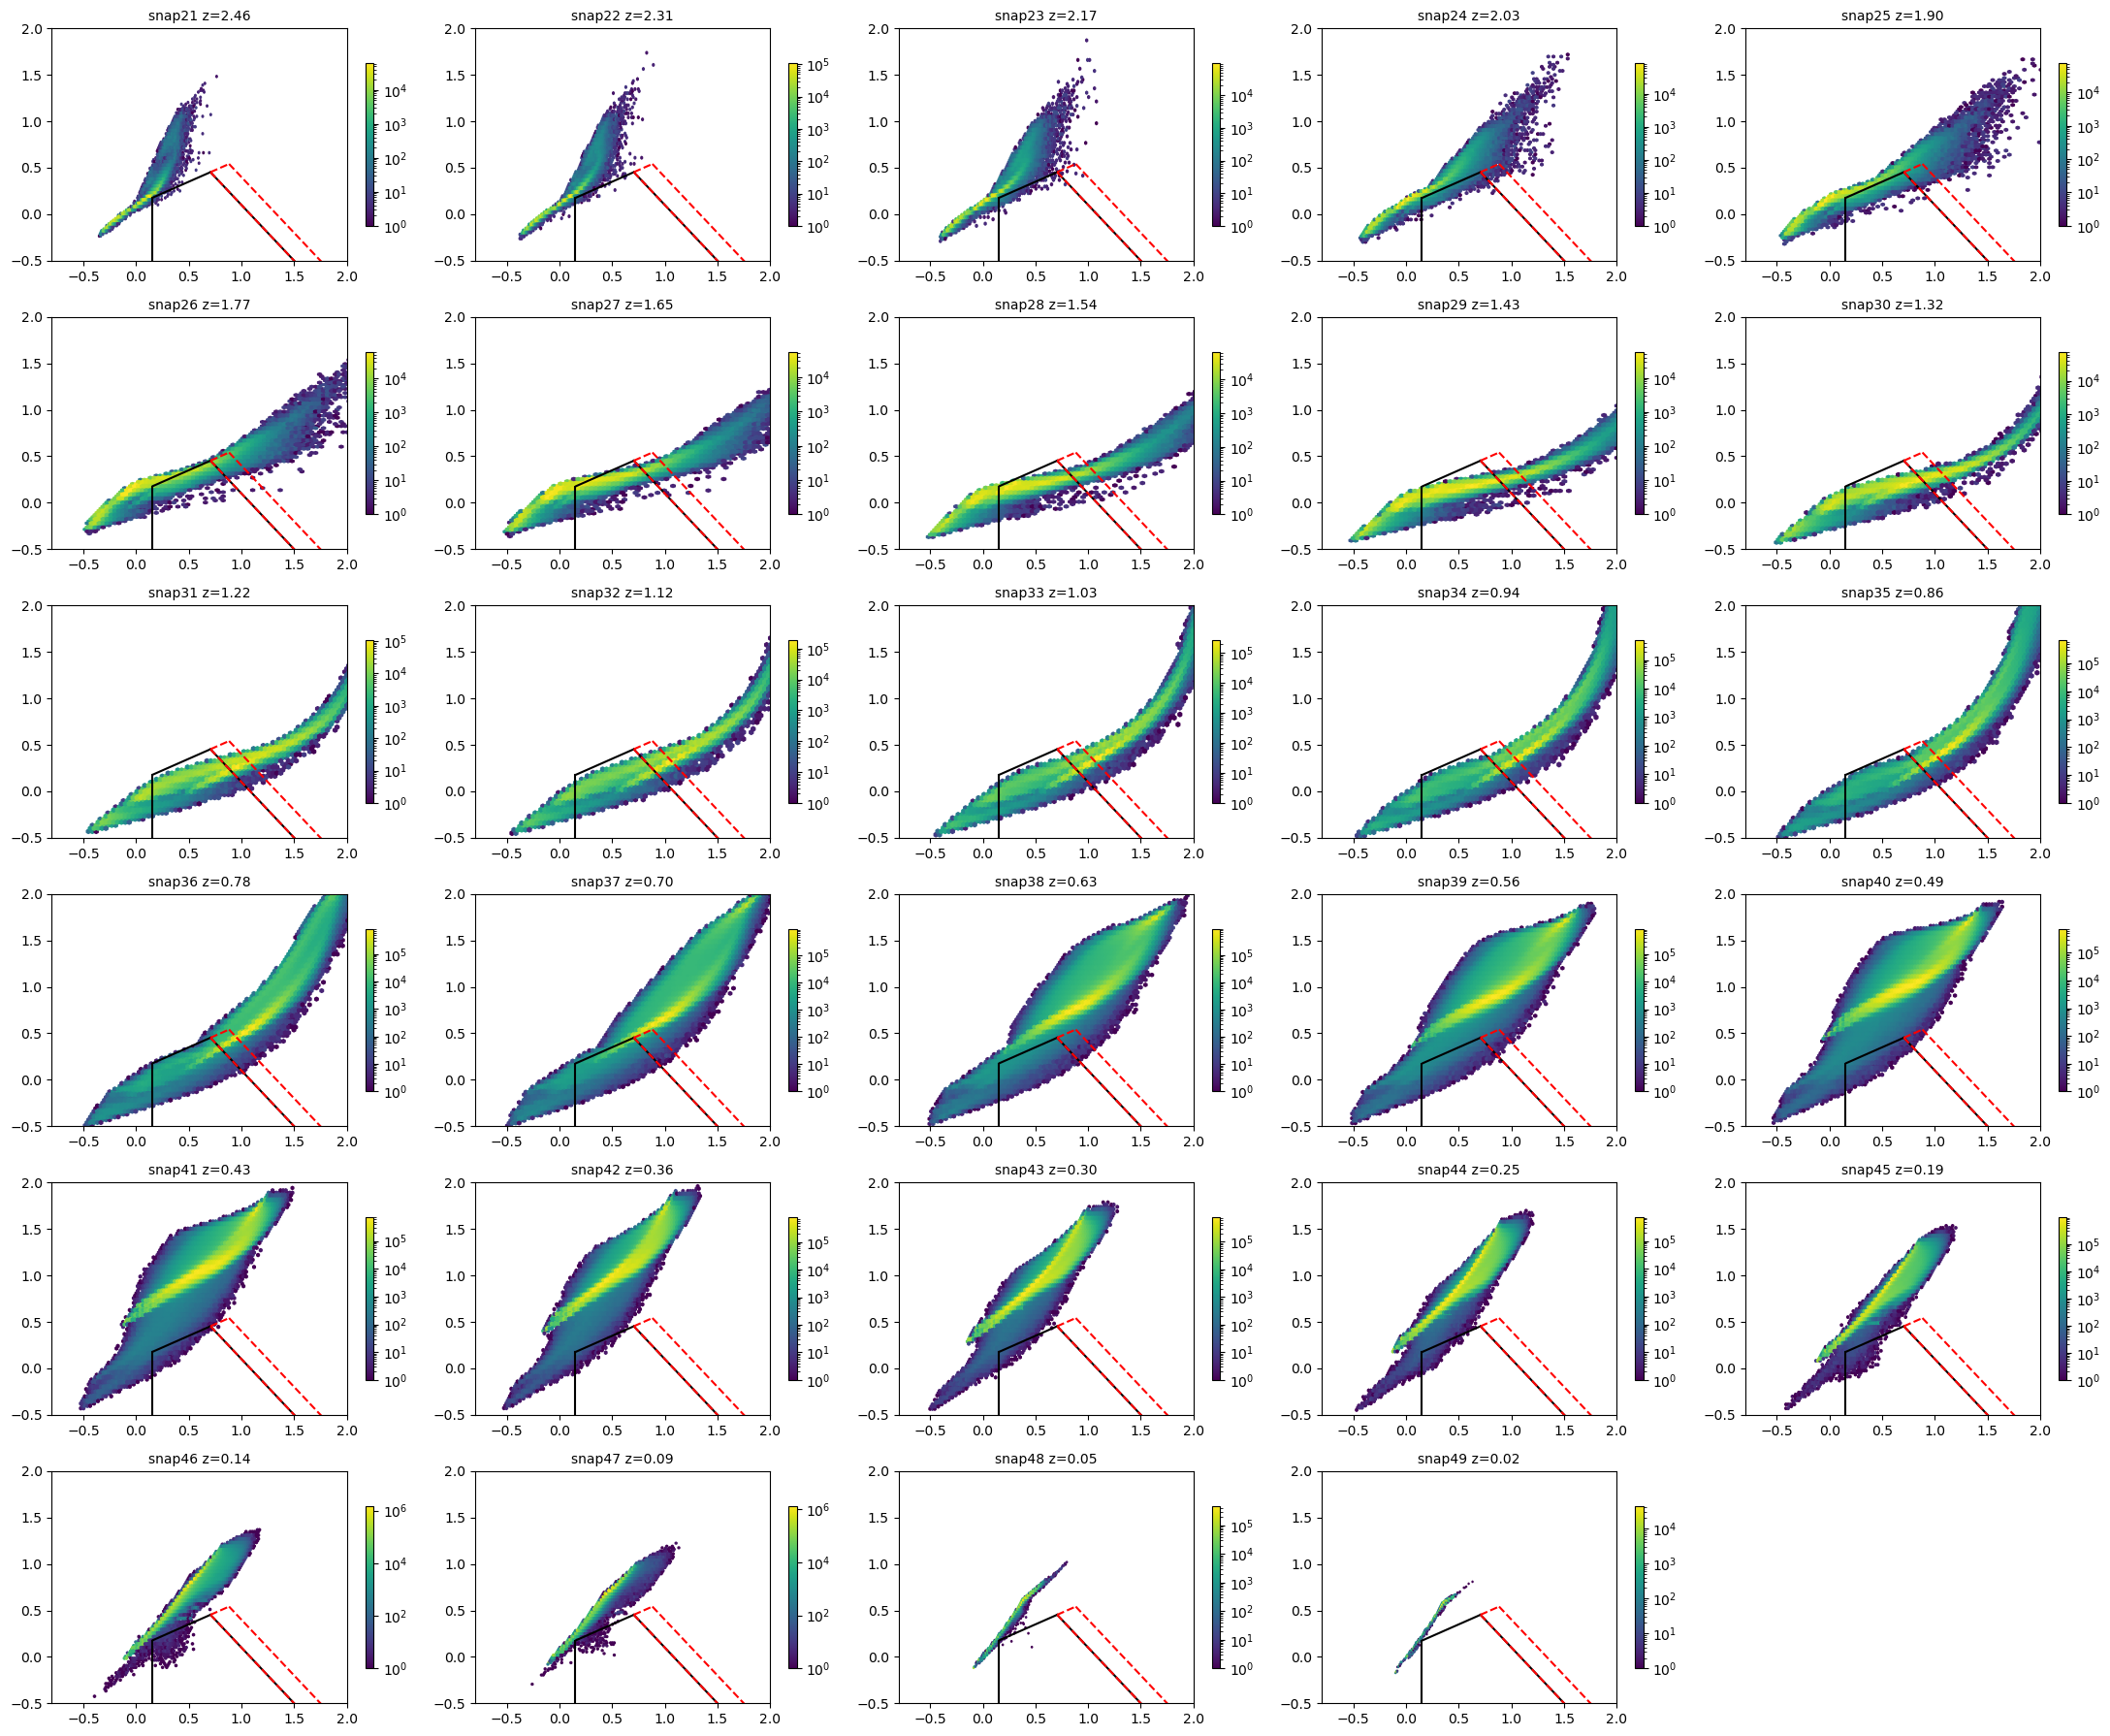

In [15]:
fig, axes = plt.subplots(6, 5, figsize=(22, 18))
axes = axes.ravel()

for idx, i in enumerate(SNAPS):
    ax = axes[idx]

    zsnap, g, r, z, _ = load_magnitudes(i)
    rz, gr, m = make_gr_rz(g, r, z)

    hb = ax.hexbin(rz, gr, gridsize=80, bins='log')
    fig.colorbar(hb, ax=ax, shrink=0.7)

    ax.plot(x1, elg_lop_upper_line(x1), lw=1.5, color="black")
    ax.plot(x2, elg_vlo_upper_line(x2), lw=1.5, color="red", linestyle="--")
    ax.plot(x3, elg_lower_line(x3),     lw=1.5, color="black")
    ax.plot(x4, elg_lower_line(x4),     lw=1.5, color="red", linestyle="--")
    ax.plot(x1,  elg_lop_upper_line(x1), lw=1.5, color="red", linestyle="--")
    ax.plot([elg_rz_min(), elg_rz_min()], [-0.5, 0.175], lw=1.5, color="black")#rz = 0.15 交点は0l175

    ax.set_xlim(-0.8, 2.0)
    ax.set_ylim(-0.5, 2.0)
    ax.set_title(f"snap{i} z={zsnap:.2f}", fontsize=10)

for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## mean z color-map

In [16]:
x_min, x_max = -0.8, 2.0       # r - z
y_min, y_max = -0.5, 2.0  
nx, ny = 200, 200

x_edges = np.linspace(x_min, x_max, nx+1)
y_edges = np.linspace(y_min, y_max, ny+1)

N_tot   = np.zeros((nx, ny), dtype=float)
Zsum_tot = np.zeros((nx, ny), dtype=float) 

for idx, i in enumerate(SNAPS):
    ax = axes[idx]

    zsnap, g, r, z, _ = load_magnitudes(i)
    rz, gr, m = make_gr_rz(g, r, z)

    H_N, _, _ = np.histogram2d(rz, gr, bins=[x_edges, y_edges])
    
    weights_z = np.full_like(rz, zsnap, dtype=float)
    H_Z, _, _ = np.histogram2d(rz, gr, bins=[x_edges, y_edges],
                               weights=weights_z)

    N_tot    += H_N
    Zsum_tot += H_Z

print("[info] All snapshots processed.") 

[info] All snapshots processed.


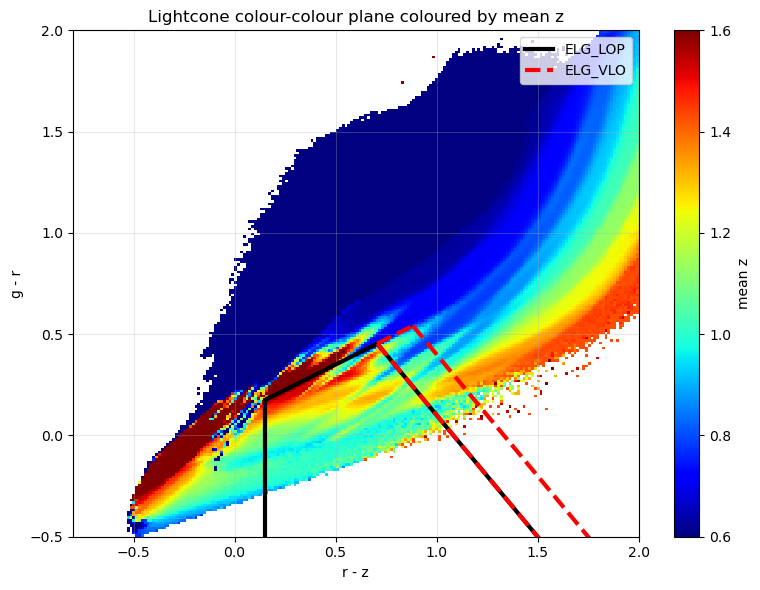

In [17]:
with np.errstate(invalid="ignore", divide="ignore"):
    z_mean = Zsum_tot / N_tot
z_mean[N_tot == 0] = np.nan 

fig, ax = plt.subplots(figsize=(8, 6))

pcm = ax.pcolormesh(
    x_edges, y_edges, z_mean.T,
    shading="auto",
    vmin=0.6,
    vmax=1.6,
    cmap="jet"
)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("mean z")
cbar.set_ticks([0.6, 0.8, 1.0, 1.2, 1.4, 1.6])


ax.plot(x1, elg_lop_upper_line(x1), lw=3, color="black", label="ELG_LOP")
ax.plot(x2, elg_vlo_upper_line(x2), lw=3, color="red", linestyle="--", label="ELG_VLO")
ax.plot(x3,  elg_lower_line(x3), lw=3, color="black")
ax.plot(x4,  elg_lower_line(x4), lw=3, color="red", linestyle="--")
ax.plot(x1,  elg_lop_upper_line(x1), lw=3, color="red", linestyle="--")
ax.plot([elg_rz_min(), elg_rz_min()], [-0.5, 0.175], lw=3, color="black")

ax.set_xlabel("r - z")
ax.set_ylabel("g - r")
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("Lightcone colour-colour plane coloured by mean z")
ax.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()